# Niobrara Housing Study

Bobbi Petit, AICP (FIVE RULE Rural Planning)  
Jordan Duffin Wong, Ph.D [](https://orcid.org/0009-0005-6984-2980)

In [ ]:
# These are the R packages used to generate this section.
library(extrafont) # Font manager

Registering fonts with R

Loading required package: ggplot2

Linking to GEOS 3.13.0, GDAL 3.8.5, PROJ 9.5.1; sf_use_s2() is TRUE

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ stringr   1.6.0
✔ forcats   1.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     

── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter()     masks stats::filter()
✖ dplyr::group_rows() masks kableExtra::group_rows()
✖ dplyr::lag()        masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

## Purpose

Upon completion of the Study, the community’s leadership and housing stakeholders will move forward by continuing to take the following steps.

1.  Seek Partnerships: Continue working with other agencies, organizations, and neighboring jurisdictions to leverage resources.
2.  Explore Funding Opportunities: The Federal and State governments understand that the lack of affordable housing is affecting the entire country. As such, Federal and State programs continue to be made available to governments committed to solving housing problems on a local scale. With the knowledge of the state of their community, they must stay informed about programs that provide financial resources or incentives for affordable housing and infrastructure improvements.
3.  Recognize Achievements and Share Best Practices: Recognize and celebrate successful housing development initiatives within the community. Share best practices, lessons learned, and success stories with other cities and regions to promote knowledge sharing, collaborative learning, and mutual growth.

## Process

The Housing Study documents the conditions, statuses, and needs for housing in Niobrara. Drawing on a variety of data from the Knox County, Nebraska Property Assessor, various government agencies, and original surveys of Niobrara residents, we show that Niobrara has a long-term trend of population decline and housing structures in need of improvement.

## Housing Condition and Age

The status and the condition of the residential structures in Knox County are documented by the Knox County Property Assessor. They use five ratings:[1]

1.  **Worn Out**: homes that are in a state of severe disrepair or uninhabitable condition.

2.  **Badly Worn**: homes that have serious deficiencies in systems, such as roofing, plumbing, or electrical foundation. They also show visible deterioration.

3.  **Average**: homes that are habitable and maintain a standard level of functionality. They may lack modern updates or show signs of aging and general wear.

4.  **Good**: homes that are newer, well-maintained, or recently renovated.

5.  **Very Good**: homes that are extremely new, extremely well-maintained, and feature modern amenities and features.

The map below displays the housing conditions in Niobrara.

[1] The Assessor also calculates intermediate ratings, e.g. “Worn Out - Badly Worn.”

In [ ]:
housing_condition <- read_sf(
  dsn = "data/shapefiles/shp-parcel-inventory/shp-parcel-inventory.shp"
) %>%
  filter(
    sprbndr %in%
      c("Niobrara"),
    etj == 1,
    type == "Residential",
    !is.na(conditn)
  ) %>%
  select(Prcl_ID, conditn, geometry) %>%
  rename("Parcel_ID" = "Prcl_ID", "Condition" = "conditn") %>%
  mutate(
    Condition = factor(
      Condition,
      levels = c(
        "Worn-Out",
        "Worn-Out - Badly Worn",
        "Badly Worn",
        "Badly Worn - Average",
        "Average",
        "Average - Good",
        "Good",
        "Good - Very Good",
        "Very Good"
      )
    )
  ) %>%
  st_transform(crs = 4326)

mapview::mapview(housing_condition,
                 zcol = "Condition",
                 map.types = c("CartoDB.Positron", "Esri.WorldImagery"),
                 col.regions = c("#3D0C02", "#79443B", "#FF0800", "#FF7F50", "#FFBF00", "#C0FF00", "#32CD32", "#01796F", "#007FFF"),
                 alpha.regions = c(0.75),
                 lwd = 1.5,
                 layer.name = "Housing Condition")

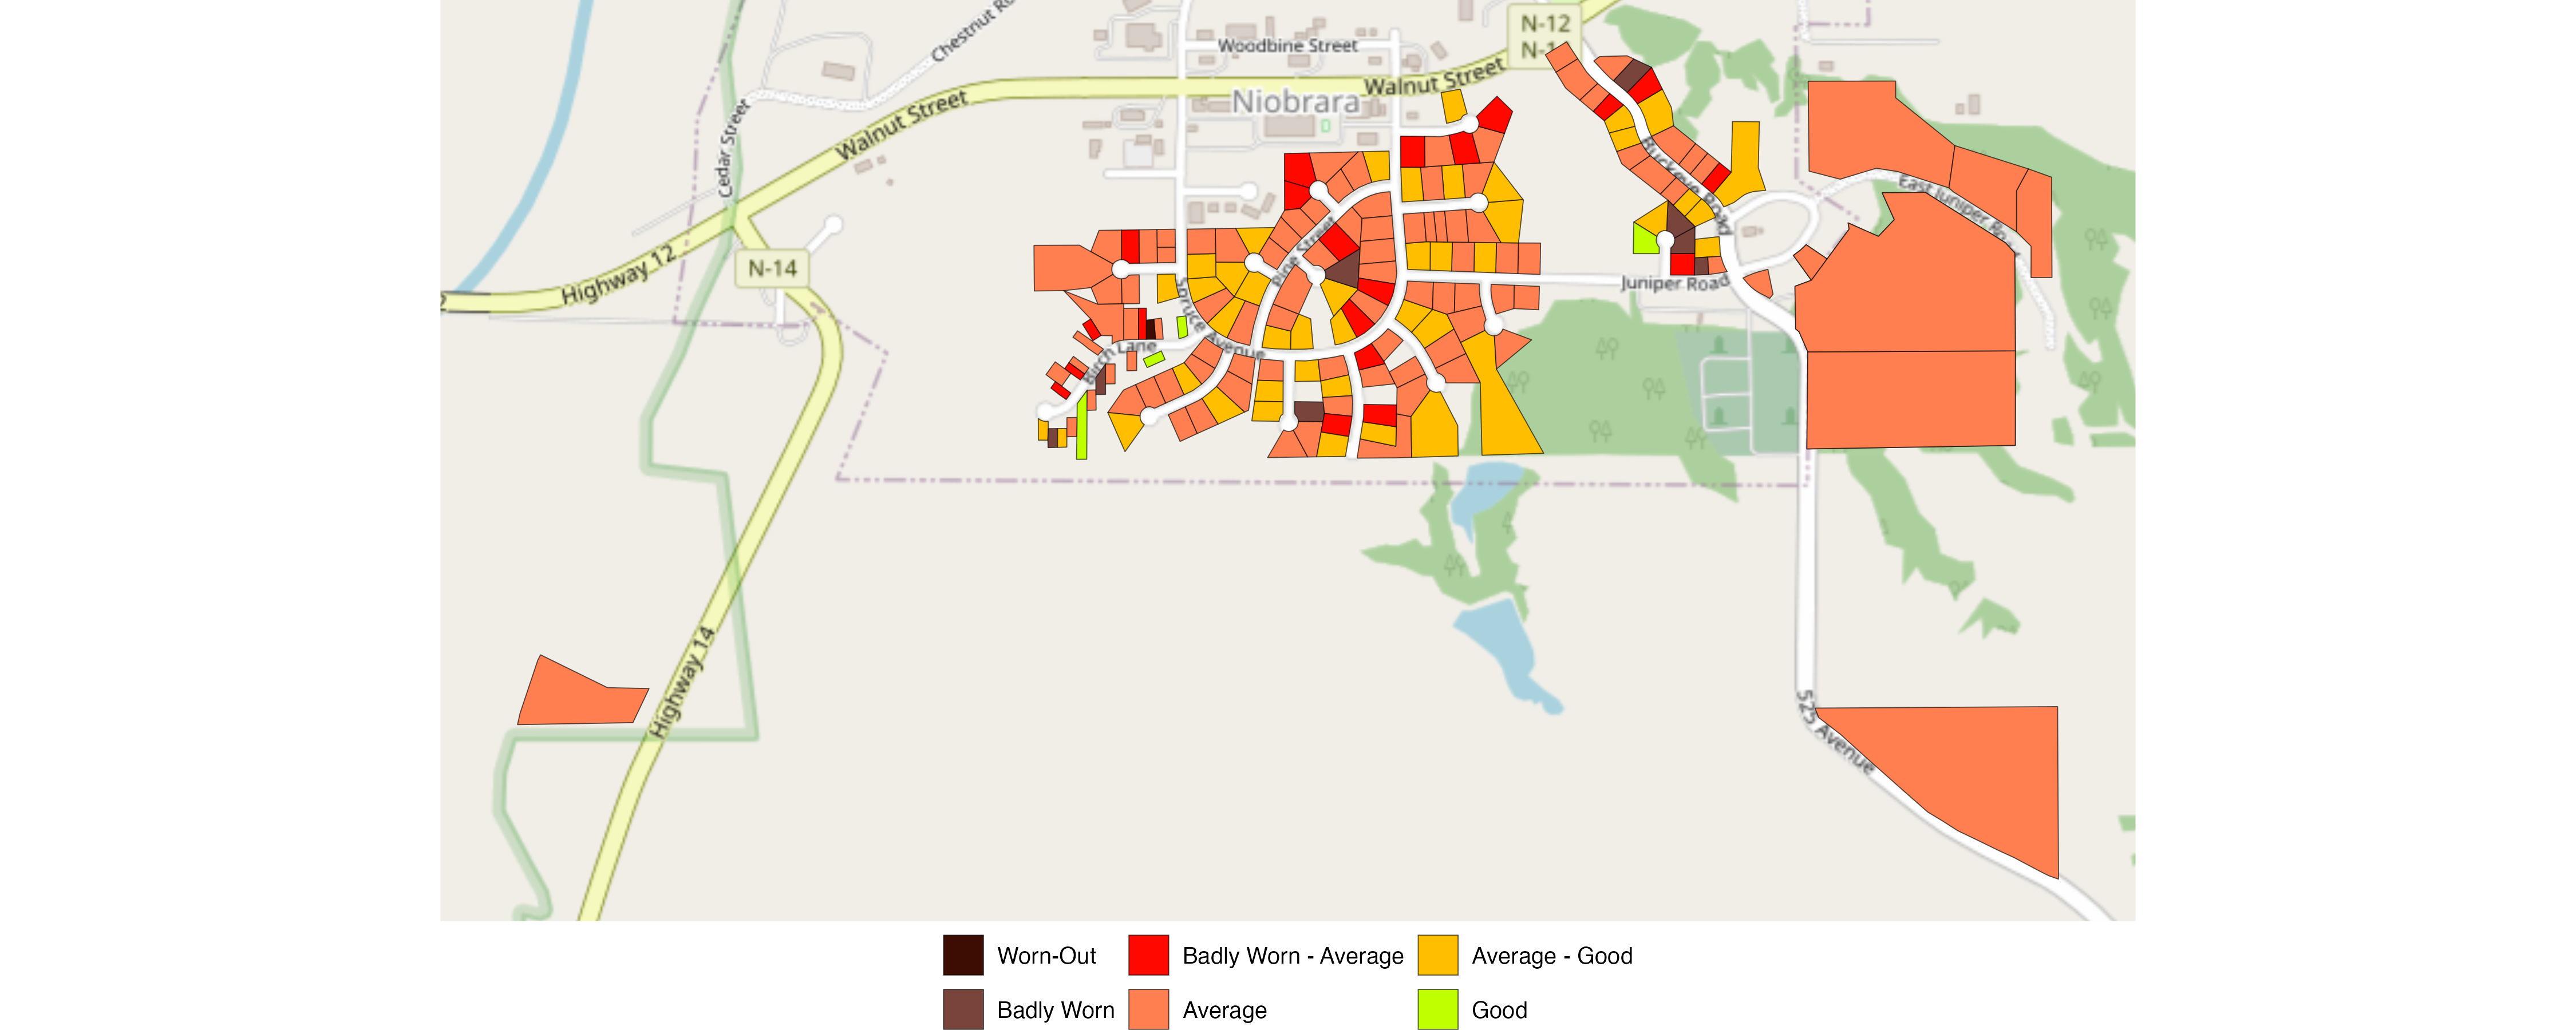

<br>

We tabulate the condition of the residential housing structures across Niobrara as well.

In [ ]:
load(file = "Tables/tab_housing_conditions_all.Rda")

kable(tab_housing_condition, align = c("l", "c", "c", "c"), format.args = list(big.mark = ",")) %>%
  kable_styling(bootstrap_options = c("striped", "hover"), position = "left", full_width = F,
                   fixed_thead = T, latex_options = c("striped", "HOLD_position", "repeat_header")) %>%
  row_spec(row = 0, color = "white", background = "gray") %>%
  column_spec(3, width = "15em")

We have several remarks on the housing conditions of Western Knox County:

1.  The overwhelming majority of housing is in **average** condition:
    - About **90%** of the homes in Western Knox County are habitable and maintain a standard level of functionality. However, they may lack modern updates or show signs of aging and general wear.

    - This indicates a stable but aging housing stock, which eventually requires investment in maintenance or modernization.
2.  Very few homes are **worn out**:
    - Only **0.10%** (one tenth of one percent) of homes are in a state of severe disrepair or uninhabitable condition.[1] This reflects a minimum standard of basic housing adequacy across Western Knox County, with little evidence of total structural abandonment.

    - It also suggests that code enforcement or demolition efforts may be effective in preventing extreme blight.
3.  A small proportion of houses are **badly worn**:
    - About **5%** of the housing stock is assessed as “badly worn” or “badly worn - average.” These homes may have serious deficiencies in systems (such as roofing, plumbing, or electrical foundation) or visible deterioration.

    - This group represents homes that are likely still occupied but nearing the point where repairs and renovation are critical.
4.  A similarly small proportion of houses are **good or better**:
    - Only about **5%** of homes are rated better than “average,” suggesting a small segment of housing stock that is newer, well-maintained, or recently renovated. This could indicate limited recent investment in high-quality residential development or upgrades.

    - It also highlights the need for incentives and programs to support home improvement or new building efforts.

**Overall Implications for Housing Policy**: the data paint a picture of a largely-functional housing stock, but one that is aging and moderately deteriorated. The low percentage of “good” and share of “badly worn” houses suggests that regions across Western Knox County may benefit from targeted housing rehabilitation programs, especially centered on owner-occupied homes in poor condition. Grant funding an development efforts could be focused on preventing the decline of average-rated homes while prioritizing repairs for the five percent of badly-worn stock.

The Knox County Property Assessor also documents the age of housing structures. Knowing the age of community housing stock is important because the workable lifespan of a typical house is about one hundred years. Many of the homes in Western Knox County are more than a century old, indicating that action is necessary to keep the overall housing stock up to date.

[1] According to the property assessor, at least.

In [ ]:
load(file = "tables/tab_housing_age_all.Rda")

kable(tab_housing_age, align = c("l", "c", "c", "c"), format.args = list(big.mark = ",")) %>%
  kable_styling(bootstrap_options = c("striped", "hover"), position = "left", full_width = F,
                   fixed_thead = T, latex_options = c("striped", "HOLD_position", "repeat_header")) %>%
  row_spec(row = 0, color = "white", background = "gray") %>%
  column_spec(2, width = "15em")

In [ ]:
housing_age <- read_sf(
  dsn = "data/shapefiles/shp-parcel-inventory/shp-parcel-inventory.shp"
) %>%
  filter(
    sprbndr %in%
      c("Niobrara"),
    etj == 1,
    type == "Residential",
    !is.na(decade)
  ) %>%
  select(Prcl_ID, decade, geometry) %>%
  rename("Parcel_ID" = "Prcl_ID", "Decade" = "decade") %>%
  mutate(
    Decade = factor(
      Decade,
      levels = c(
        "Before 1900",
        "1900 - 1919",
        "1920 - 1939",
        "1940 - 1959",
        "1960 - 1979",
        "1980 - 1999",
        "2000 or later"
      )
    )
  ) %>%
  st_transform(crs = 4326)

mapview::mapview(
  housing_age,
  zcol = "Decade",
  map.types = c("CartoDB.Positron", "Esri.WorldImagery"),
  col.regions = c(
      "#3D0C02",
      "#79443B",
      "#FF0800",
      "#FF7F50",
      "#FFBF00",
      "#C0FF00",
      "#32CD32",
      "#01796F",
      "#007FFF"
  ),
  alpha.regions = c(0.75),
  lwd = 1.5,
  layer.name = "Housing Age"
)

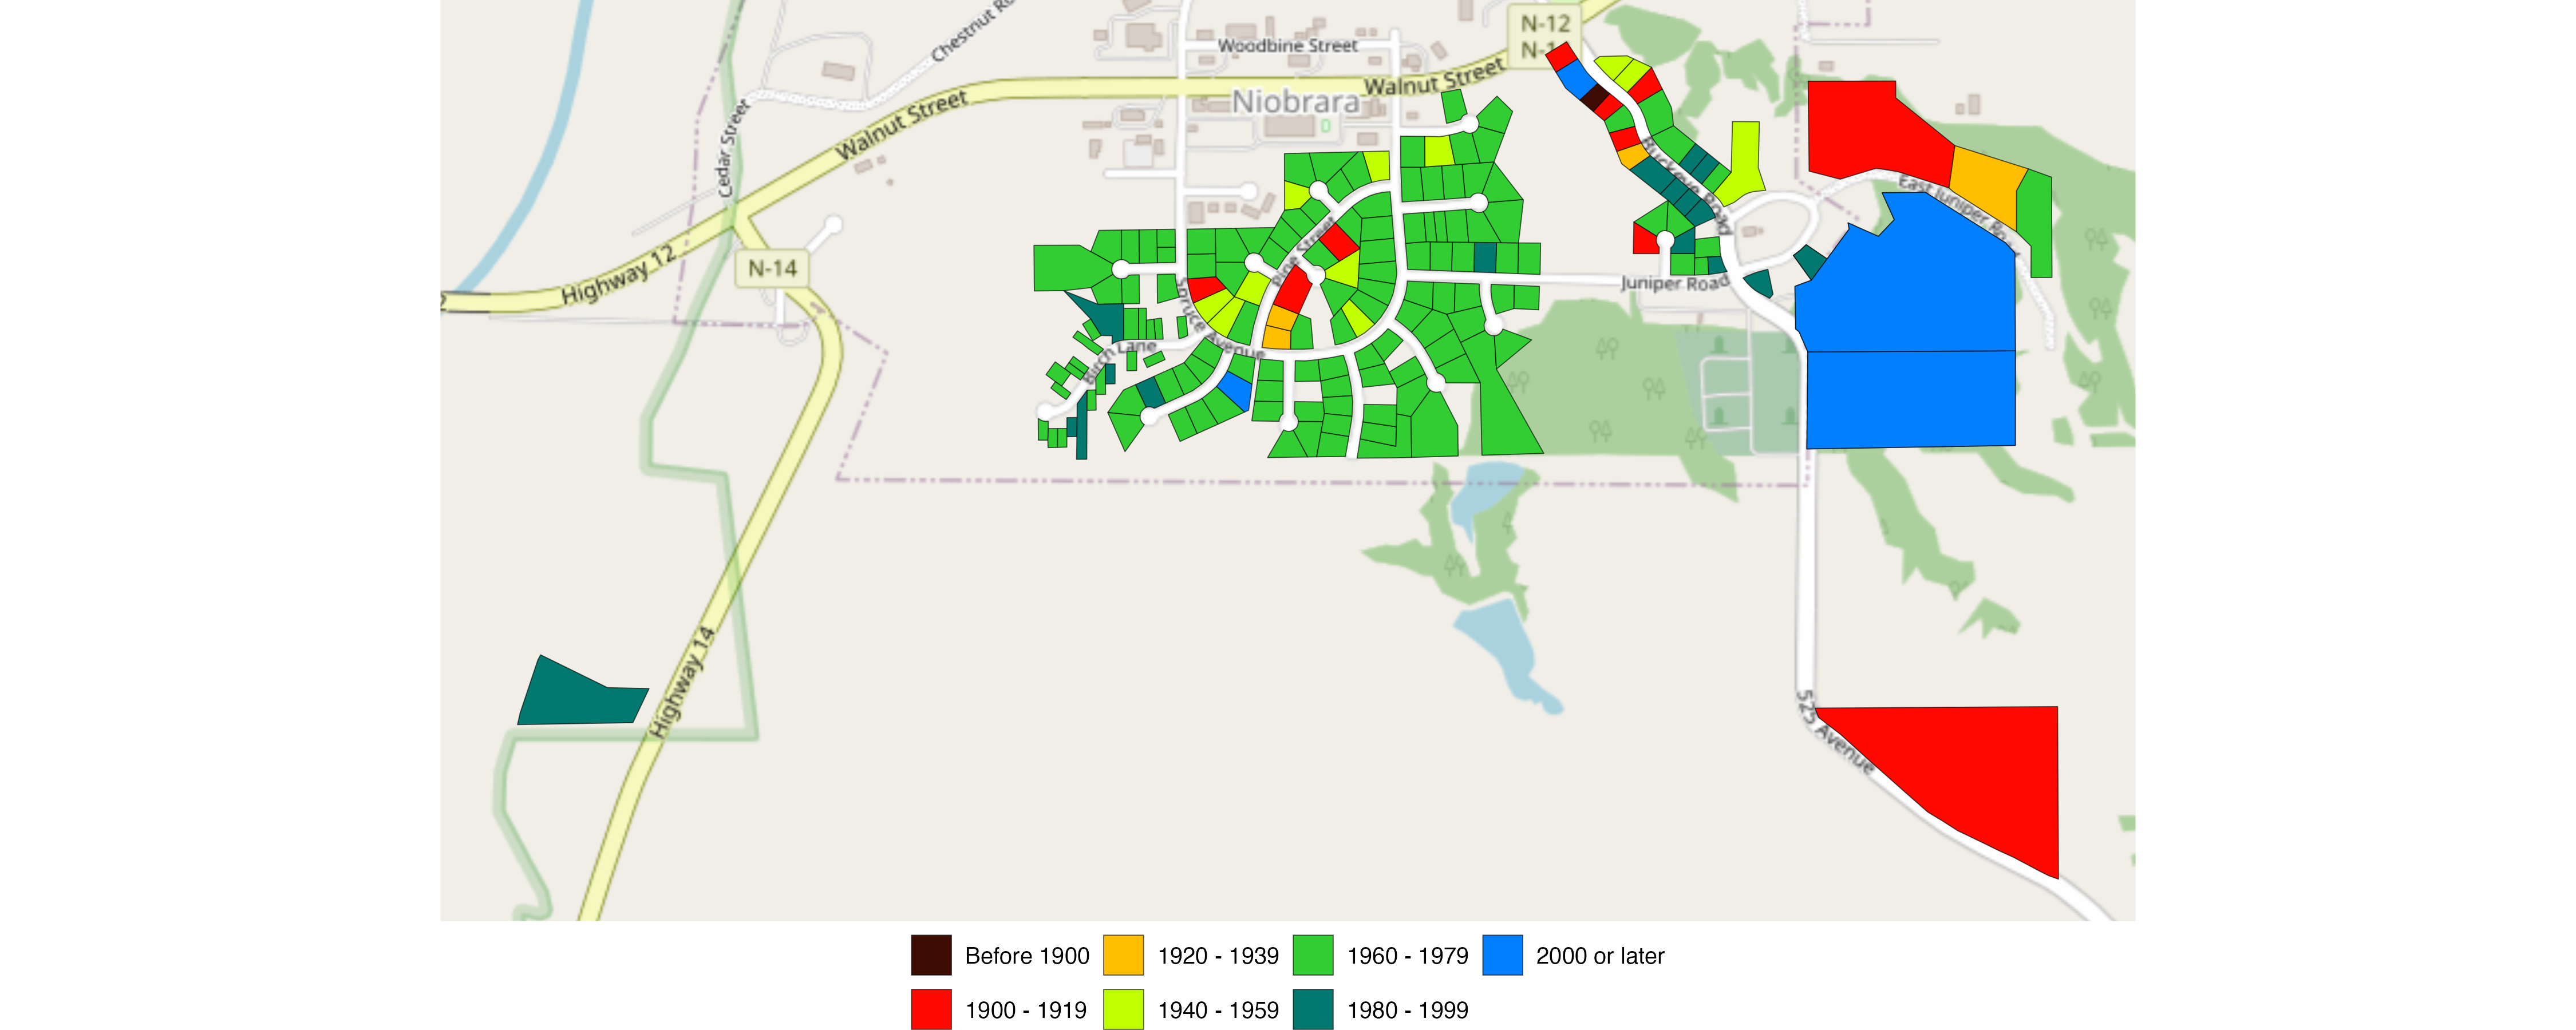